In [50]:
from tensorflow import keras
from keras.datasets import boston_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# (x_train, y_train), (x_test, y_test) = keras.datasets.boston_housing.load_data(path="boston_housing.npz", test_split=0.2, seed=113)
(x_train, y_train), (x_test, y_test) = boston_housing.load_data(test_split=0.2)

In [54]:
print(x_train.shape)
print(len(x_train))
print(x_train[0])
print(y_train[0])

(404, 13)
404
[  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]
15.2


In [14]:
model = keras.Sequential()
# model.add(BatchNormalization()) Das geht nicht!!!
model.add(keras.layers.Dense(32, activation="relu", input_shape=(x_train.shape[1],)))
model.add(keras.layers.Dense(16, activation="relu"))
model.add(keras.layers.Dense(1)) # Default activation = relu

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                448       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 993
Trainable params: 993
Non-trainable params: 0
_________________________________________________________________


In [46]:
model.fit(x_train, y_train, epochs=32, batch_size=8, verbose=0)

In [47]:
model.evaluate(x_test, y_test)

4/4 [==============================] - 0s 2ms/step - loss: 55.2207 - mae: 5.5289


[55.22071838378906, 5.528851509094238]

<AxesSubplot:>

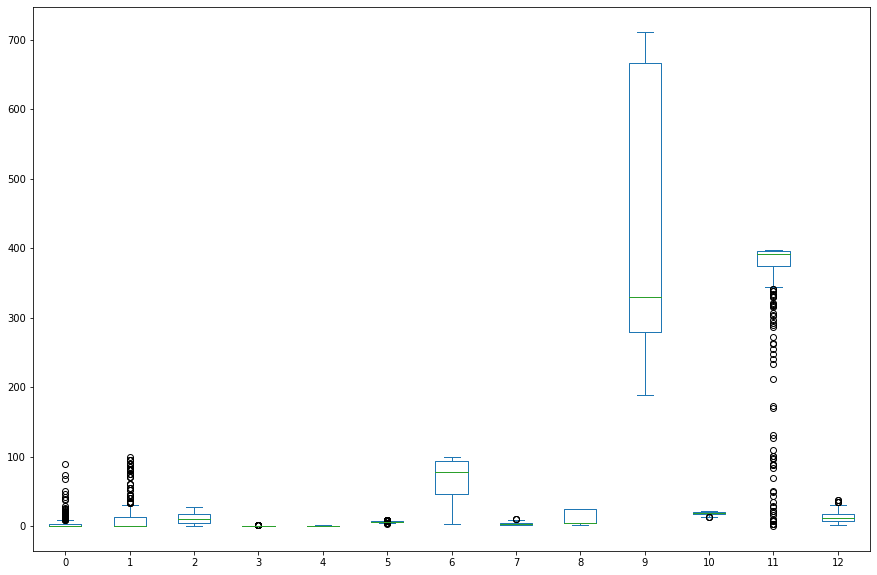

In [49]:
df_xtrain = pd.DataFrame(x_train)
df_xtest = pd.DataFrame(x_test)
df_xtrain.plot(kind="box", figsize=(15,10))

<AxesSubplot:>

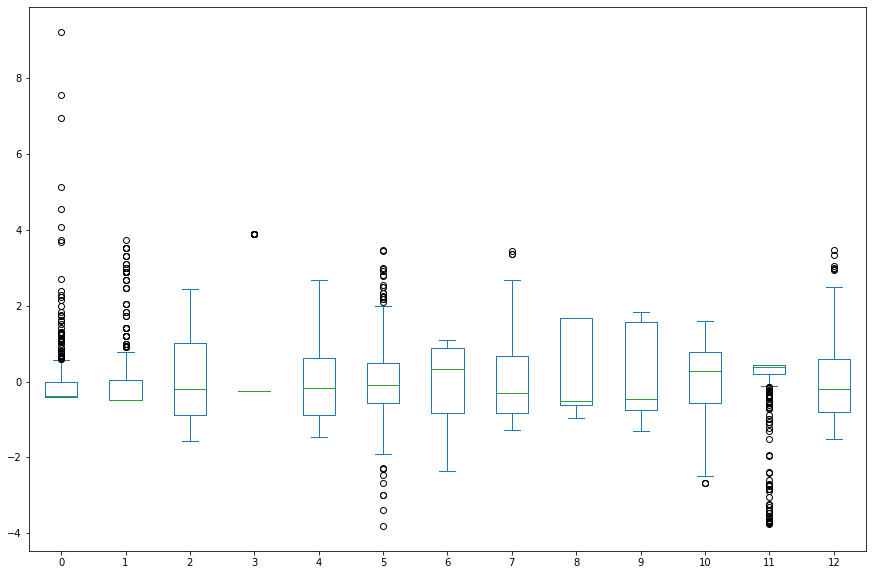

In [23]:
# Normalisierung
df_xtrain_new = (df_xtrain-df_xtrain.mean())/df_xtrain.std()
df_xtest_new = (df_xtest-df_xtest.mean())/df_xtest.std()
df_xtrain_new.plot(kind="box", figsize=(15,10))

In [24]:
# 19.1.3
x_train = df_xtrain_new.to_numpy()
x_test = df_xtest_new.to_numpy()

In [25]:
model.fit(x_train, y_train, epochs=32, batch_size=8, verbose=0)

In [26]:
model.evaluate(x_test, y_test)

4/4 [==============================] - 0s 1ms/step - loss: 21.3144 - mae: 3.0563


[21.314428329467773, 3.056349277496338]